# AG-HYPOPT · Trial 07

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Six trials are recorded. Best remains trial_05 (sw 0.844, h_f 3.903, h_s 3.616, cap 0.217) at objective 0.0822 (0 diverged, gamma finite; mu rel-RMSE 36.7%, gamma rel-RMSE 21.0%). trial_06 (sw 0.497, h_f 4.0, h_s 3.876, cap 0.104) is second at 0.0861 (mu 34.0% best, but gamma 30.1% worse - lower sw and smaller cap hurt gamma). Then trial_03 (0.1040), trial_04 (0.1177), trial_01 (0.1243), trial_02 (0.1287). All 0 diverged, gamma finite. The picture: flat kernels (h_f, h_s high) plus a strong sigma weight (~0.85) and a modest gamma cap (~0.2) define the best region; a moderate sigma weight (~0.5) with maximally flat kernels matches but does not beat it. Phase 'trials' (trials-informed TPE).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_07'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (6/5 trials)
ID |     ei | params
 1 | 3.9243 | {"gamma_rel_cap": 0.23442411494281754, "h_f_scale": 3.956789712533272, "h_s_scale": 3.525825420235982, "sigma_weight": 0.8212284183827663}
 2 | 0.0990 | {"gamma_rel_cap": 0.06834299465809549, "h_f_scale": 1.2940960453779, "h_s_scale": 1.9190361470599246, "sigma_weight": 0.9645591986641635}
 3 | 3.0513 | {"gamma_rel_cap": 0.07762847723250757, "h_f_scale": 3.840935644670775, "h_s_scale": 0.8507951269669171, "sigma_weight": 0.8911756535936051}
 4 | 3.9532 | {"gamma_rel_cap": 0.25744441013568514, "h_f_scale": 3.877188586914801, "h_s_scale": 3.630953946944224, "sigma_weight": 0.761551749491627}
 5 | 0.3500 | {"gamma_rel_cap": 0.3460160604409196, "h_f_scale": 1.635761164758275, "h_s_scale": 3.362678986756546, "sigma_weight": 0.26759930456378545}
 6 | 3.9630 | {"gamma_rel_cap": 0.10735617789825944, "h_f_scale": 4.0, "h_s_scale": 3.674548492934102, "sigma_weight": 0.8648862719598797}
 7 | 3.8977 | {"gamma_rel_cap": 0.2177742272871

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The best region is well defined now: flat kernels (h_f, h_s high) together with a strong sigma weight (~0.85) and a modest gamma cap (~0.2) - trial_05 (0.0822). trial_06 showed that a moderate sw (0.50) with max-flat kernels only matches it (0.0861, gamma worse). The batch contains a tight cluster of high-ei draws in exactly this region (ids 1, 4, 6, 7, 8 all ei ~3.9-3.96).

Candidate 6 (ei 3.963, the highest) combines both features of the two best trials at once: sigma_weight 0.865 (trial_05's strong sigma link) with h_f = 4.0 (trial_06's maximally flat FWHM kernel) and h_s 3.675 (flat), plus a small gamma cap 0.107. It is the most direct test of whether the best region can be improved by taking the strong sw of trial_05 and the max-flat kernels of trial_06 together.

I choose candidate 6.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6               # candidate 6: sigma_weight 0.865, h_f_scale 4.0, h_s_scale 3.675, gamma_rel_cap 0.107 (strong sw + max-flat kernels)


chosen: {'gamma_rel_cap': 0.10735617789825944, 'h_f_scale': 4.0, 'h_s_scale': 3.674548492934102, 'sigma_weight': 0.8648862719598797}
Running  1nW Trans05 ... 

μ 9.39 -> 6.07 | γ 8.5 -> 6.34 | NLL 0.25


Running  1nW Trans20 ... 

μ 17.32 -> 27.71 | γ 8.5 -> 5.43 | NLL 0.65


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 62.96 | γ 14.1 -> 14.02 | NLL 0.70


Running 3nW Trans100 ... 

μ 175.71 -> 98.65 | γ 14.1 -> 13.82 | NLL 0.61



Total: 7.5 min


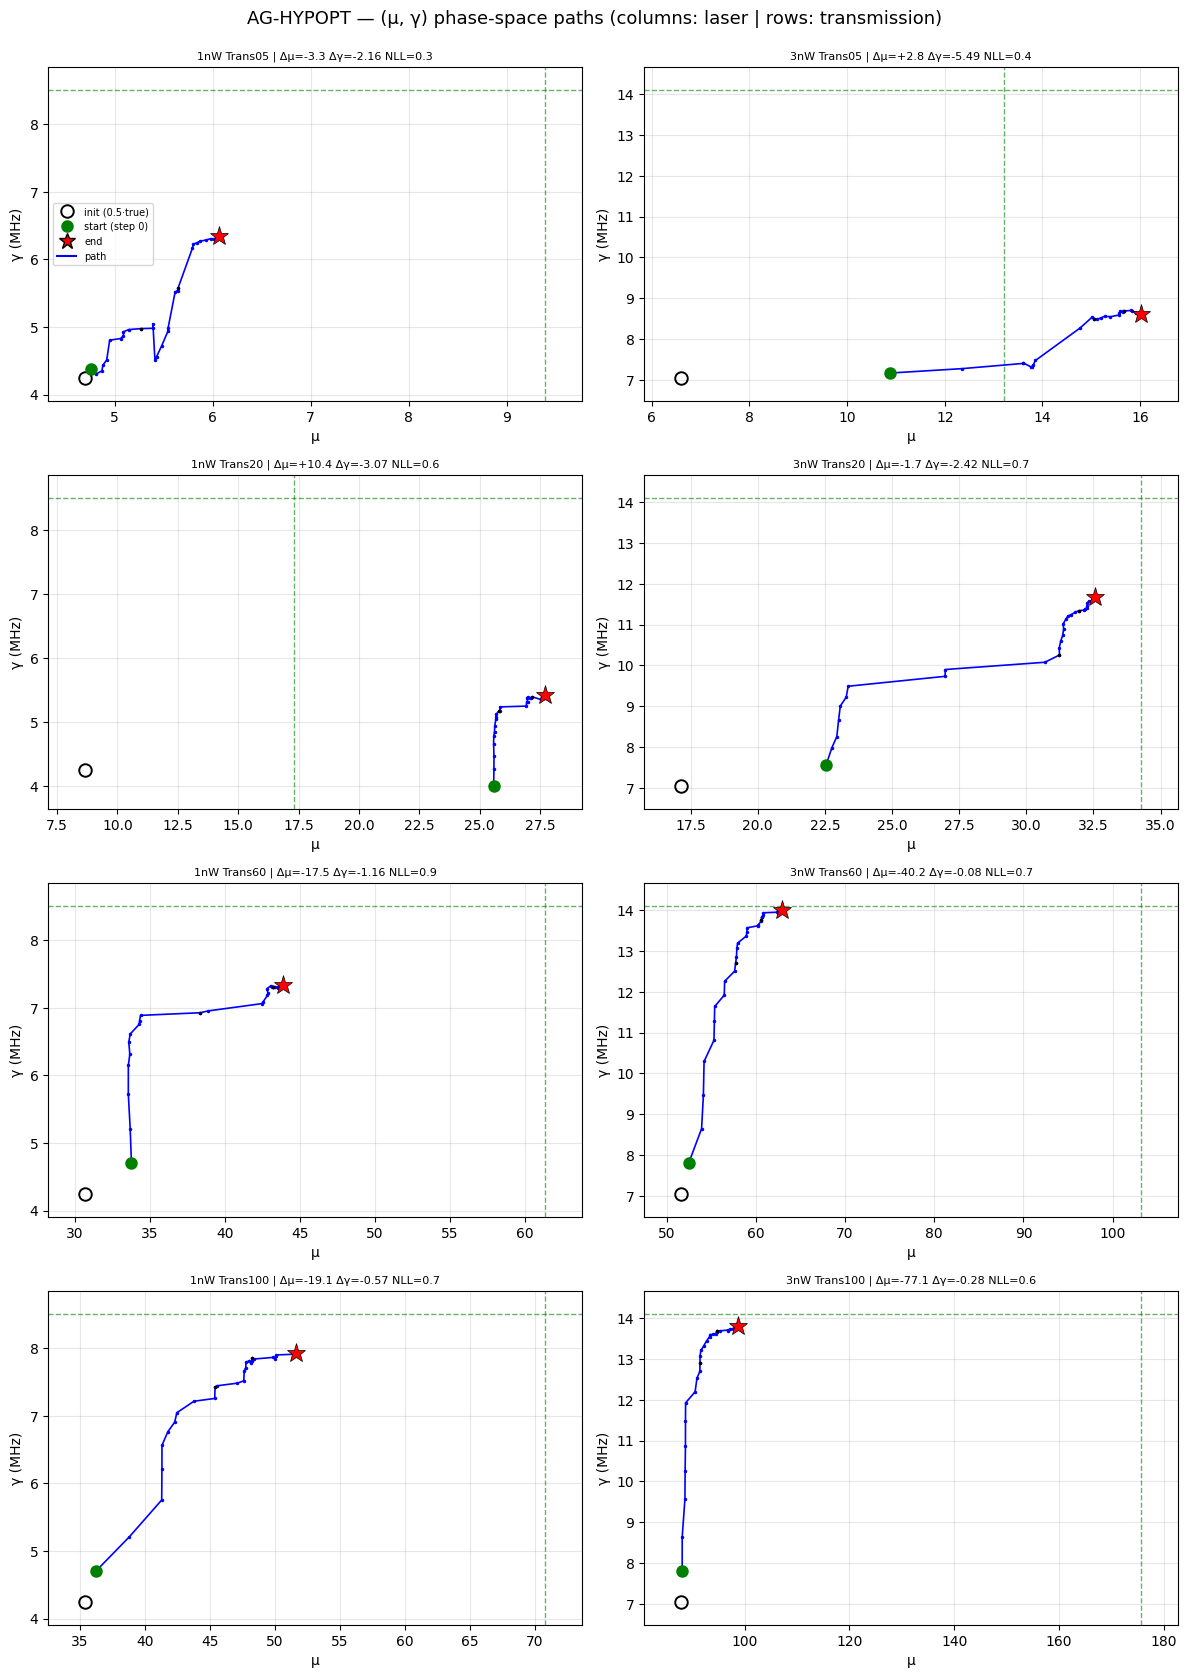

trial finished in 7.6 min
objective = 0.0803 ± 0.0239
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    6.07   -35.4 |     8.50    6.34   -25.4
1nW Trans20       17.32   27.71   +60.0 |     8.50    5.43   -36.1
1nW Trans60       61.37   43.86   -28.5 |     8.50    7.34   -13.6
1nW Trans100       70.82   51.68   -27.0 |     8.50    7.93    -6.7
3nW Trans05       13.20   16.02   +21.3 |    14.10    8.61   -39.0
3nW Trans20       34.28   32.54    -5.1 |    14.10   11.68   -17.1
3nW Trans60      103.20   62.96   -39.0 |    14.10   14.02    -0.6
3nW Trans100      175.71   98.65   -43.9 |    14.10   13.82    -2.0

weighted objective (T-graded, cap=1.0) = 0.0803 | diverged cells: 0
μ: RMSE 32.326 (rel 35.9%, bias -18.225) | γ: RMSE 2.545 (rel 22.3%, bias -1.903)


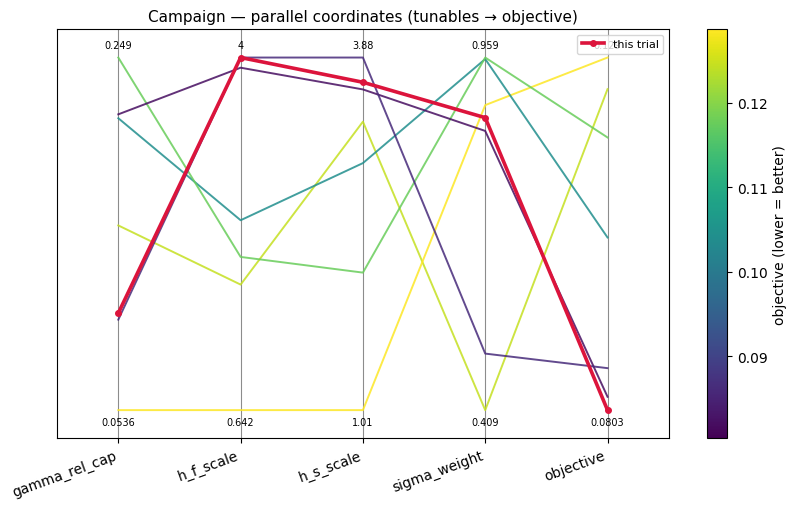

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 07 (sw 0.865, h_f 4.0, h_s 3.675, cap 0.107) ran to completion in 7.6 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0803 +/- 0.0239 - a new best, marginally better than trial_05 (0.0822).

mu rel-RMSE 35.9% (similar to trial_05's 36.7%; best remains trial_06's 34.0%): the persistent shape - high-T undershoot (3nW Trans100 -43.9%, 3nW Trans60 -39.0%, 1nW Trans60 -28.5%, 1nW Trans100 -27.0%) and low-T overshoot (1nW Trans20 +60.0%, 3nW Trans05 +21.3%); bias -18.23.

gamma rel-RMSE 22.3%, essentially at trial_05's 21.0% (best) and clearly better than trial_06's 30.1%, so the strong sigma weight restored the gamma channel; low T still under-estimated (3nW Trans05 -39.0%, 1nW Trans20 -36.1%, 1nW Trans05 -25.4%) while high T is near truth (-0.6%, -2.0%).

The candidate combined both features of the two prior best trials - the strong sigma weight of trial_05 and the maximally flat kernels of trial_06 - and edged both, so the two design choices are complementary rather than redundant; the objective is now at 0.0803, well under the exp5 level and the 0.1074 headline.

**Summary:** Trial 07 (sw=0.865, h_f=4.0, h_s=3.675, cap=0.107) finished in 7.6 min with 0 diverged cells and gamma finite, objective 0.0803 +/- 0.0239 - new best, marginally over trial_05's 0.0822 (mu rel-RMSE 35.9%, gamma rel-RMSE 22.3%).
**Key insight:** Combining trial_05's strong sigma weight (0.865) with trial_06's maximally flat kernels (h_f 4.0, h_s 3.68) gave the new best 0.0803, so the two design choices are complementary rather than redundant.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 07 (sw=0.865, h_f=4.0, h_s=3.675, cap=0.107): objective 0.0803 +/- 0.0239 - new best, marginally over trial_05; 0 diverged cells, gamma finite (mu rel-RMSE 35.9%, gamma rel-RMSE 22.3%).'
KEY_INSIGHT = 'Combining trial_05 strong sigma weight (0.865) with trial_06 max-flat kernels (h_f 4.0, h_s 3.68) gave the new best 0.0803, so the two design choices are complementary rather than redundant.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_07 | current best: trial_07


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_08.ipynb. Open it and follow its cells from the top.
